# Agitation prediction: Prediction models

**Author:** Eva Rombouts  
**Date:** 19-07-2024  
**Version:** 1.0 

### Description
In this script, models are trained and evaluated for predicting agitation in nursing home notes. Both Random Forest and Logistic Regression models are trained. 
The dataset used for training and validation was generated using ChatGPT, which explains the excelent performance. For this reason we will focus on false positives and false negatives, to further annotate these in the future. 

In [1]:
# Environment setup
import os

def check_environment():
    try:
        import google.colab
        return "Google Colab"
    except ImportError:
        return "Local Environment"

env = check_environment()
if env == "Google Colab":
    print("Running in Google Colab")
    # !pip install -q
    from google.colab import drive, userdata
    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/GenCareAI/scripts/200_agitation_models')
else:
    print("Running in Local Environment")
    # !pip install -q scikit-learn matplotlib


Running in Local Environment


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [3]:
seed = 6

In [4]:
# Load the datasets
train_df = pd.read_csv('../../data/agitation_train.csv')
valid_df = pd.read_csv('../../data/agitation_valid.csv')
test_df = pd.read_csv('../../data/agitation_test.csv')

In [5]:
# Define feature columns
feature_columns = [col for col in train_df.columns if col.startswith('topic_') or col.startswith('embedding_')]
# feature_columns = [col for col in train_df.columns if col.startswith('topic_')]
# feature_columns = [col for col in train_df.columns if col.startswith('embedding_')]

# Prepare training and validation data
X_train = train_df[feature_columns]
y_train = train_df['label']
X_valid = valid_df[feature_columns]
y_valid = valid_df['label']
X_test = test_df[feature_columns]
y_test = test_df['label']

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25864 entries, 0 to 25863
Data columns (total 60 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          25864 non-null  object 
 1   label         25864 non-null  int64  
 2   text_clean    25864 non-null  object 
 3   topic_0       25864 non-null  float64
 4   topic_1       25864 non-null  float64
 5   topic_2       25864 non-null  float64
 6   topic_3       25864 non-null  float64
 7   topic_4       25864 non-null  float64
 8   topic_5       25864 non-null  float64
 9   topic_6       25864 non-null  float64
 10  embedding_0   25864 non-null  float64
 11  embedding_1   25864 non-null  float64
 12  embedding_2   25864 non-null  float64
 13  embedding_3   25864 non-null  float64
 14  embedding_4   25864 non-null  float64
 15  embedding_5   25864 non-null  float64
 16  embedding_6   25864 non-null  float64
 17  embedding_7   25864 non-null  float64
 18  embedding_8   25864 non-nu

## Random forest

In [7]:
# Initialize the model
rf_model = RandomForestClassifier(random_state=seed)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=6)

Validation Results:
Confusion Matrix:
[[7576   21]
 [  82  943]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7597
           1       0.98      0.92      0.95      1025

    accuracy                           0.99      8622
   macro avg       0.98      0.96      0.97      8622
weighted avg       0.99      0.99      0.99      8622


Accuracy Score:
0.9880538158199954


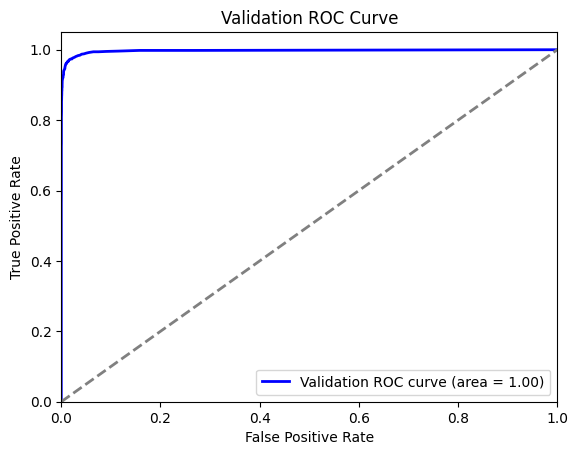

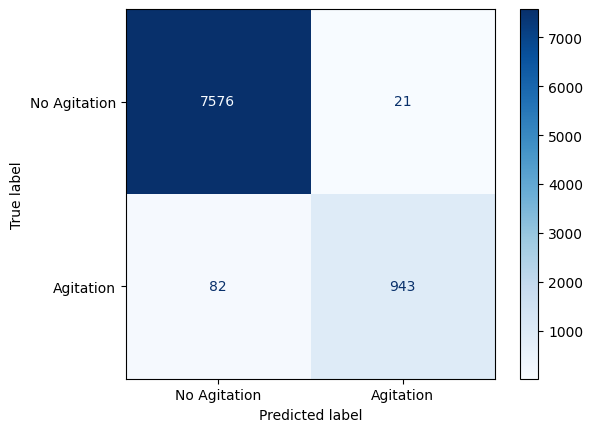

In [8]:
# Validate the model
y_valid_pred_rf = rf_model.predict(X_valid)
y_valid_pred_proba_rf = rf_model.predict_proba(X_valid)[:, 1]

# Print evaluation metrics
print("Validation Results:")
print("Confusion Matrix:")
cm = confusion_matrix(y_valid, y_valid_pred_rf)
print(cm)
print("\nClassification Report:")
print(classification_report(y_valid, y_valid_pred_rf))
print("\nAccuracy Score:")
print(accuracy_score(y_valid, y_valid_pred_rf))

# Compute AUC and plot ROC curve for validation data
valid_auc = roc_auc_score(y_valid, y_valid_pred_proba_rf)
fpr_valid, tpr_valid, _ = roc_curve(y_valid, y_valid_pred_proba_rf)

plt.figure()
plt.plot(fpr_valid, tpr_valid, color='blue', lw=2, label=f'Validation ROC curve (area = {valid_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Validation ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Display contingency table
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Agitation', 'Agitation'])
cm_display.plot(cmap=plt.cm.Blues)
plt.show()

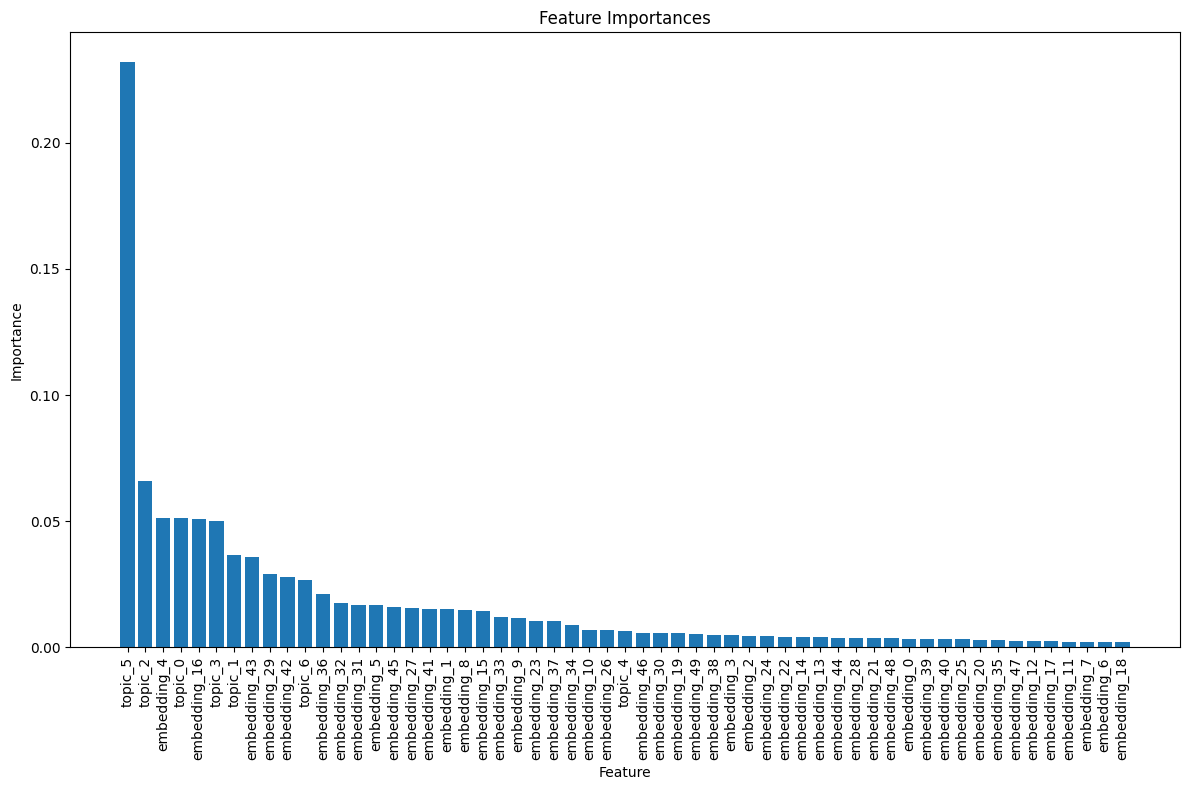

In [9]:
# Get feature importances
importances = rf_model.feature_importances_
feature_names = feature_columns

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

# Rearrange the feature names so they match the sorted feature importances
sorted_feature_names = [feature_names[i] for i in indices]

# Plot the feature importances
plt.figure(figsize=(12, 8))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## Logistic Regression Model

In [10]:
lr_model = LogisticRegression(random_state=seed, max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=6)

Validating Logistic Regression model...
Logistic Regression - Validation Results:
Confusion Matrix:
[[7505   92]
 [ 114  911]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7597
           1       0.91      0.89      0.90      1025

    accuracy                           0.98      8622
   macro avg       0.95      0.94      0.94      8622
weighted avg       0.98      0.98      0.98      8622


Accuracy Score:
0.9761076316399907


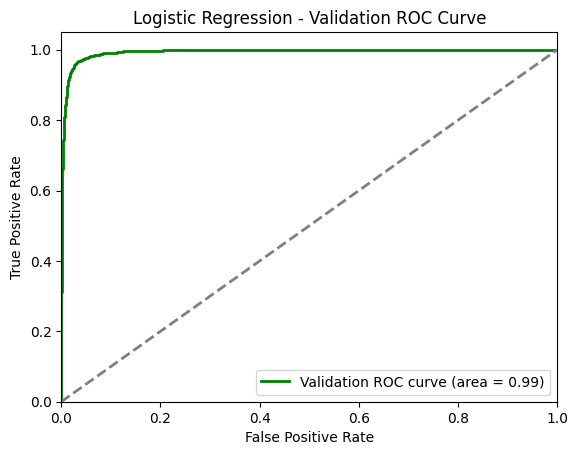

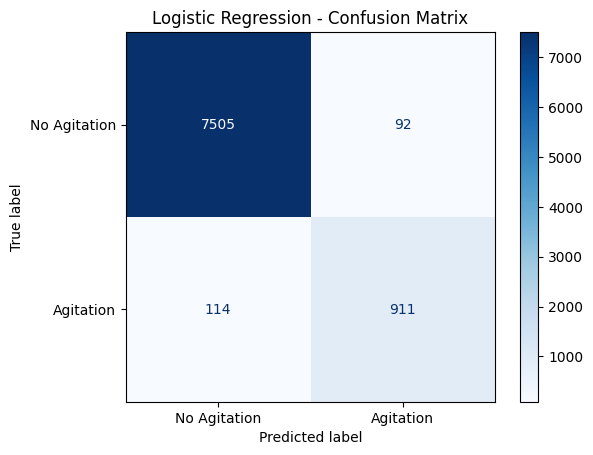

In [11]:

# Validate Logistic Regression model
print("Validating Logistic Regression model...")
y_valid_pred_lr = lr_model.predict(X_valid)
y_valid_pred_proba_lr = lr_model.predict_proba(X_valid)[:, 1]

# Print evaluation metrics for Logistic Regression
print("Logistic Regression - Validation Results:")
print("Confusion Matrix:")
cm_lr = confusion_matrix(y_valid, y_valid_pred_lr)
print(cm_lr)
print("\nClassification Report:")
print(classification_report(y_valid, y_valid_pred_lr))
print("\nAccuracy Score:")
print(accuracy_score(y_valid, y_valid_pred_lr))

# Compute AUC and plot ROC curve for Logistic Regression validation data
valid_auc_lr = roc_auc_score(y_valid, y_valid_pred_proba_lr)
fpr_valid_lr, tpr_valid_lr, _ = roc_curve(y_valid, y_valid_pred_proba_lr)

plt.figure()
plt.plot(fpr_valid_lr, tpr_valid_lr, color='green', lw=2, label=f'Validation ROC curve (area = {valid_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression - Validation ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Display confusion matrix for Logistic Regression
cm_display_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Agitation', 'Agitation'])
cm_display_lr.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

Getting coefficients for Logistic Regression...


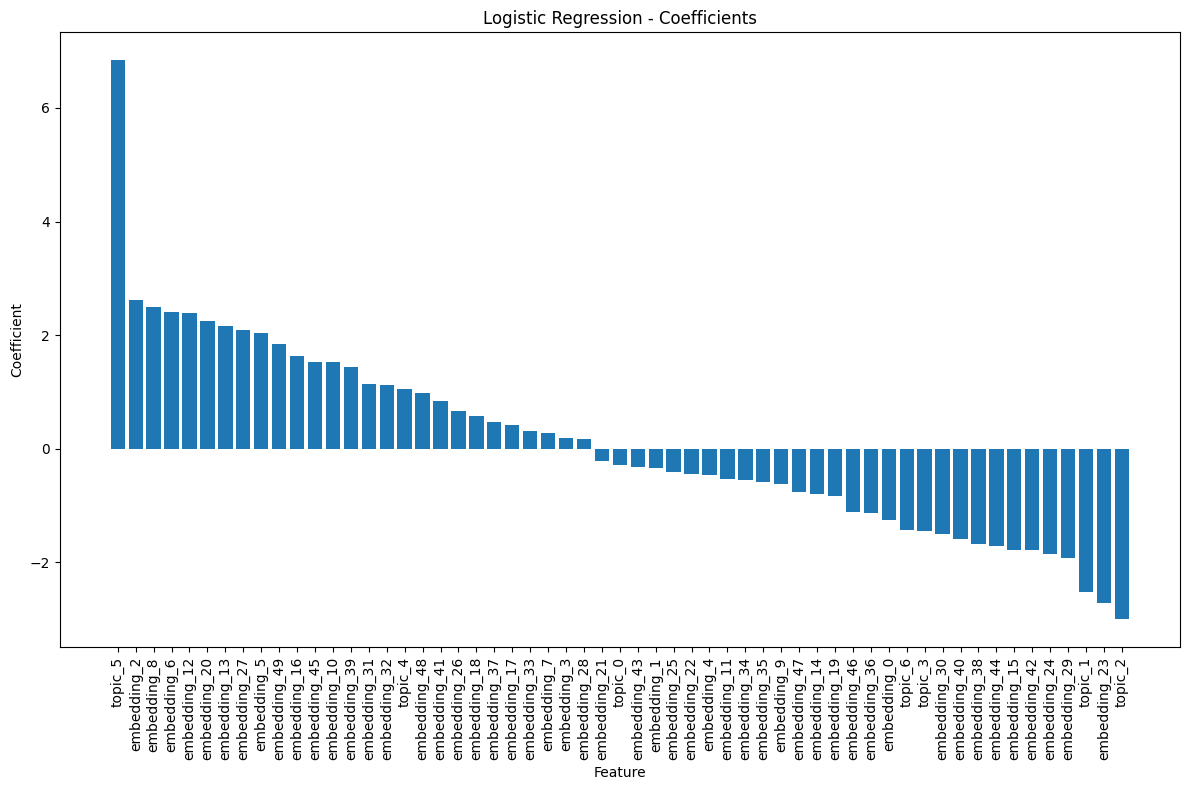

In [12]:
# Coefficients for Logistic Regression
print("Getting coefficients for Logistic Regression...")
coefficients_lr = lr_model.coef_[0]
indices_lr = np.argsort(coefficients_lr)[::-1]
sorted_feature_names_lr = [feature_names[i] for i in indices_lr]

# Plot the coefficients for Logistic Regression
plt.figure(figsize=(12, 8))
plt.title("Logistic Regression - Coefficients")
plt.bar(range(len(coefficients_lr)), coefficients_lr[indices_lr], align="center")
plt.xticks(range(len(coefficients_lr)), sorted_feature_names_lr, rotation=90)
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()

## Mismatched data

In [13]:
# Identify false positives and false negatives in the validation data

# Get predictions and probabilities for both models
valid_df['rf_pred'] = y_valid_pred_rf
valid_df['rf_proba'] = y_valid_pred_proba_rf
valid_df['lr_pred'] = y_valid_pred_lr
valid_df['lr_proba'] = y_valid_pred_proba_lr

# Create a new DataFrame with the relevant columns
results_df = valid_df[['text', 'label', 'rf_pred', 'rf_proba', 'lr_pred', 'lr_proba']]

print("Results DataFrame:")
print(results_df.head())

# Save the results to a CSV file (optional)
results_df.to_csv('../../data/validation_results.csv', index=False)

Results DataFrame:
                                                text  label  rf_pred  \
0  Arts heeft geadviseerd om bloeddruk van mevrou...      0        0   
1  Dhr is ineens agressief naar de verzorgenden t...      1        1   
2  Mw. nam deel aan de bingo-activiteit vanmiddag...      0        0   
3  Mw heeft vandaag goed gebruik gemaakt van haar...      0        0   
4  Dhr. klaagde over maagpijn en misselijkheid na...      0        0   

   rf_proba  lr_pred  lr_proba  
0      0.00        0  0.000079  
1      0.93        1  0.920355  
2      0.00        0  0.000536  
3      0.00        0  0.000019  
4      0.01        0  0.000562  


In [14]:
# Create a subset where the predictions and the labels do not match
mismatched_df = results_df[(results_df['label'] != results_df['rf_pred']) | (results_df['label'] != results_df['lr_pred'])]

print("Mismatched DataFrame:")
print(mismatched_df.sample(5))

# Save the mismatched results to a CSV file (optional)
mismatched_df.to_csv('../../data/mismatched_validation_results.csv', index=False)

Mismatched DataFrame:
                                                   text  label  rf_pred  \
4565  Mw liep zoekend rond in de gang en wilde const...      1        0   
4935  Mw trekt steeds haar alarmbelletje zonder rede...      0        0   
213   Dhr weigerde vanmorgen resoluut om zijn medica...      0        1   
4807  Dhr. belde herhaaldelijk de nachtdienst voor o...      0        1   
3865  Mevrouw ligt in bed en wil absoluut niet opsta...      1        1   

      rf_proba  lr_pred  lr_proba  
4565      0.23        0  0.167765  
4935      0.13        1  0.780756  
213       0.51        1  0.624591  
4807      0.52        0  0.112238  
3865      0.63        0  0.204407  


In [15]:
mismatched_df[['label', 'rf_pred', 'lr_pred']].value_counts()

label  rf_pred  lr_pred
0      0        1          79
1      0        0          59
       1        0          55
       0        1          23
0      1        1          13
                0           8
Name: count, dtype: int64

In [16]:
import joblib

# Zorg ervoor dat de directory bestaat waar je de modellen wilt opslaan
save_dir = "../../models/agitation"
os.makedirs(save_dir, exist_ok=True)

# 1. Opslaan van het Random Forest model
model_rf_path = os.path.join(save_dir, "random_forest_model.joblib")
joblib.dump(rf_model, model_rf_path)
print(f"Random Forest model opgeslagen in: {model_rf_path}")

# 2. Opslaan van het Logistic Regression model
model_lr_path = os.path.join(save_dir, "logistic_regression_model.joblib")
joblib.dump(lr_model, model_lr_path)
print(f"Logistic Regression model opgeslagen in: {model_lr_path}")

Random Forest model opgeslagen in: ../../models/agitation/random_forest_model.joblib
Logistic Regression model opgeslagen in: ../../models/agitation/logistic_regression_model.joblib
